# Main pySTAMPS Stage Notebook

One notebook, one main branch of execution: build a fresh scratch dataset, run each pySTAMPS stage through Python functions, compare each stage to the original STAMPS oracle, and plot the evidence immediately after the stage runs.

Figma workflow: [https://www.figma.com/board/sTO94K9nWGX1Co60UXJ7QR?utm_source=codex&utm_content=edit_in_figjam&oai_id=&request_id=d4279247-6c0f-4e49-89cd-d67947f20906](https://www.figma.com/board/sTO94K9nWGX1Co60UXJ7QR?utm_source=codex&utm_content=edit_in_figjam&oai_id=&request_id=d4279247-6c0f-4e49-89cd-d67947f20906)

In [1]:
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import numpy as np

from pystamps.notebooks import (
    build_scratch_tree,
    build_stage_notebook_context,
    execute_stage,
    native_stage_notebook_config,
    plot_stage_comparison,
)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Run this notebook from the repository root")

ORACLE_ROOT = REPO_ROOT / "inputs_and_outputs" / "InSAR_dataset_test_stage8diag_hl"
SCRATCH_PARENT = REPO_ROOT / "inputs_and_outputs" / "validation_runs" / "notebook_stage_by_stage"
SCRATCH_ROOT = SCRATCH_PARENT / "fresh_run"
TOOL_ROOT = REPO_ROOT / ".cache" / "pystamps-tools" / "bin"
TRIANGLE = TOOL_ROOT / "triangle" if (TOOL_ROOT / "triangle").exists() else Path(shutil.which("triangle") or "")
SNAPHU = TOOL_ROOT / "snaphu" if (TOOL_ROOT / "snaphu").exists() else Path(shutil.which("snaphu") or "")

missing_tools = [name for name, path in {"triangle": TRIANGLE, "snaphu": SNAPHU}.items() if not path.exists()]
if missing_tools:
    raise RuntimeError(f"Missing required external tools: {', '.join(missing_tools)}")

RUN_CONFIG = native_stage_notebook_config(
    stage2_native_threads=8,
    triangle_path=TRIANGLE,
    snaphu_path=SNAPHU,
)

context = build_stage_notebook_context(
    stamps_root=ORACLE_ROOT,
    scratch_parent=SCRATCH_PARENT,
    scratch_root=SCRATCH_ROOT,
    representative_patch="PATCH_1",
    run_config=RUN_CONFIG,
    replay_stages=(),
)
RESUME_EXISTING_SCRATCH = (SCRATCH_ROOT / "PATCH_1" / "pm1.mat").exists()
if RESUME_EXISTING_SCRATCH:
    removed = build_scratch_tree(context, existing_scratch=SCRATCH_ROOT)
else:
    removed = build_scratch_tree(context)

print(f"oracle: {context.stamps_root}")
print(f"fresh scratch: {context.scratch_root}")
print(f"resuming existing fresh scratch: {RESUME_EXISTING_SCRATCH}")
print(f"stage artifacts removed before execution: {removed}")
print(f"triangle: {context.config.tools.triangle}")
print(f"snaphu: {context.config.tools.snaphu}")
print(f"stage2 native threads: {context.config.runtime.stage2_native_threads}")

oracle: <stamps-dataset>
fresh scratch: <repo-root>/inputs_and_outputs/validation_runs/notebook_stage_by_stage/fresh_run
resuming existing fresh scratch: True
stage artifacts removed before execution: 0
triangle: <repo-root>/.cache/pystamps-tools/bin/triangle
snaphu: <repo-root>/.cache/pystamps-tools/bin/snaphu
stage2 native threads: 8


## Workflow map

The same main execution branch is shown in Figma and rendered below for quick notebook context.

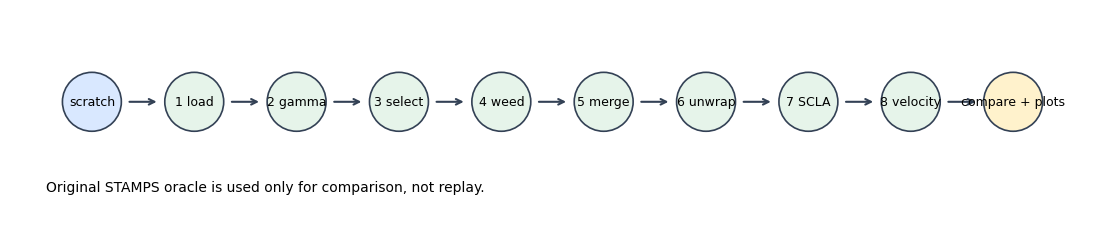

In [2]:
stages = [
    "scratch", "1 load", "2 gamma", "3 select", "4 weed",
    "5 merge", "6 unwrap", "7 SCLA", "8 velocity", "compare + plots",
]
fig, ax = plt.subplots(figsize=(14, 2.8))
x = np.arange(len(stages))
colors = ["#d9e8ff"] + ["#e6f4ea"] * 8 + ["#fff2cc"]
ax.scatter(x, np.zeros_like(x), s=1800, c=colors, edgecolor="#334155", linewidth=1.2, zorder=3)
for i in range(len(stages) - 1):
    ax.annotate("", xy=(x[i + 1] - 0.34, 0), xytext=(x[i] + 0.34, 0), arrowprops=dict(arrowstyle="->", lw=1.5, color="#334155"))
for i, label in enumerate(stages):
    ax.text(x[i], 0, label, ha="center", va="center", fontsize=9)
ax.text(-0.45, -0.58, "Original STAMPS oracle is used only for comparison, not replay.", ha="left", fontsize=10)
ax.set_xlim(-0.8, len(stages) - 0.2)
ax.set_ylim(-0.8, 0.6)
ax.axis("off")
plt.show()

## Stage 1. Initial load

Convert raw candidate files into patch-level ps1/ph1/bp1 artifacts.

**Execution mode**  
latest pySTAMPS outputs (reused scratch artifacts)

**Legacy context**  
Legacy context: patch scripts `run_stamps_p1.sh` to `run_stamps_p4.sh` call `stamps(1,4)`; pySTAMPS exposes the stage-1 load separately.

**Python stage call**
```python
run_pipeline(PipelineContext(dataset_root=<repo-root>/inputs_and_outputs/validation_runs/notebook_stage_by_stage/fresh_run, start_step=1, end_step=1, run_config=<RunConfig>))
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| PATCH_1 | patch | skipped_existing | 0.01 | ps1.mat present |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 0.02 | 2.22 | 2.25 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 5 | 5 | 0 | yes |

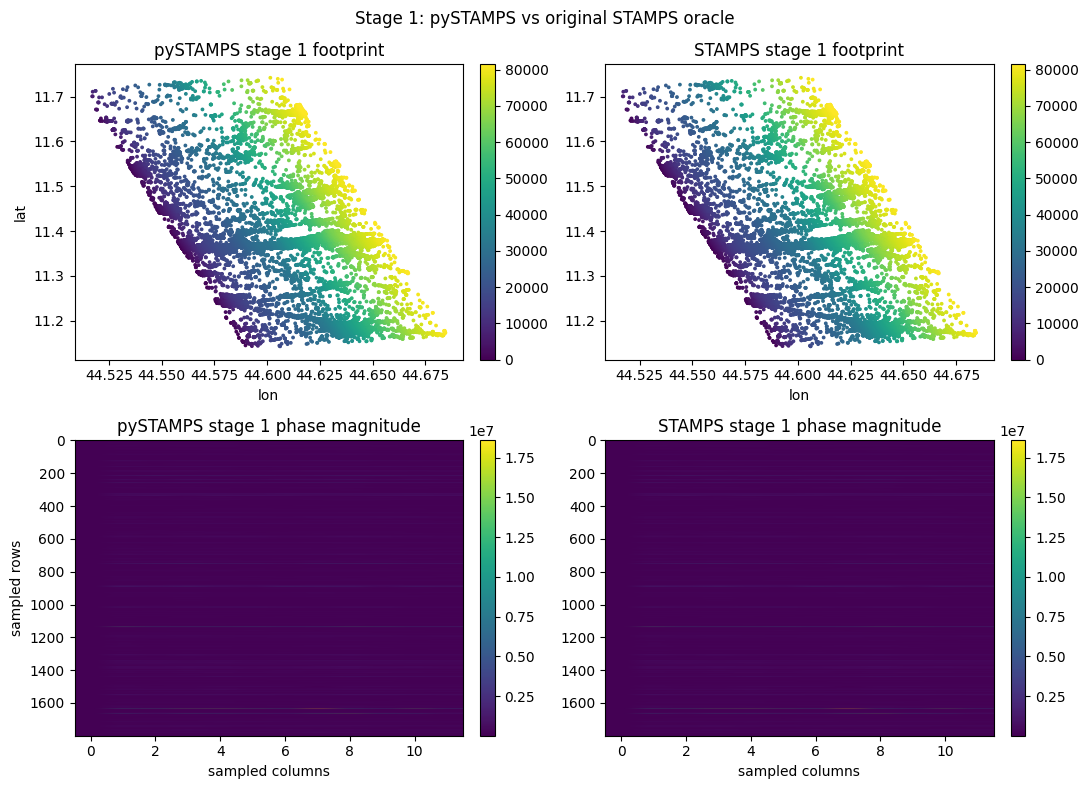

In [3]:
stage_1 = execute_stage(context, 1)
fig = plot_stage_comparison(context, 1)
plt.show()

## Stage 2. Estimate gamma

Estimate coherence, residual phase, and topographic phase terms.

**Execution mode**  
latest pySTAMPS outputs (reused scratch artifacts)

**Legacy context**  
Legacy context: this is still inside legacy `stamps(1,4)`, but pySTAMPS breaks gamma/coherence estimation into stage 2.

**Python stage call**
```python
run_pipeline(PipelineContext(dataset_root=<repo-root>/inputs_and_outputs/validation_runs/notebook_stage_by_stage/fresh_run, start_step=2, end_step=2, run_config=<RunConfig>))
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| PATCH_1 | patch | skipped_existing | 0.00 | pm1.mat present |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 0.01 | 1.52 | 1.53 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 1 | 0 | 1 | no |

**First verification failures**
| path | class | key | message |
| --- | --- | --- | --- |
| PATCH_1/pm1.mat | Stage 2 patch boundary | C_ps | Value mismatch for key 'C_ps', max_abs=1.93541 |

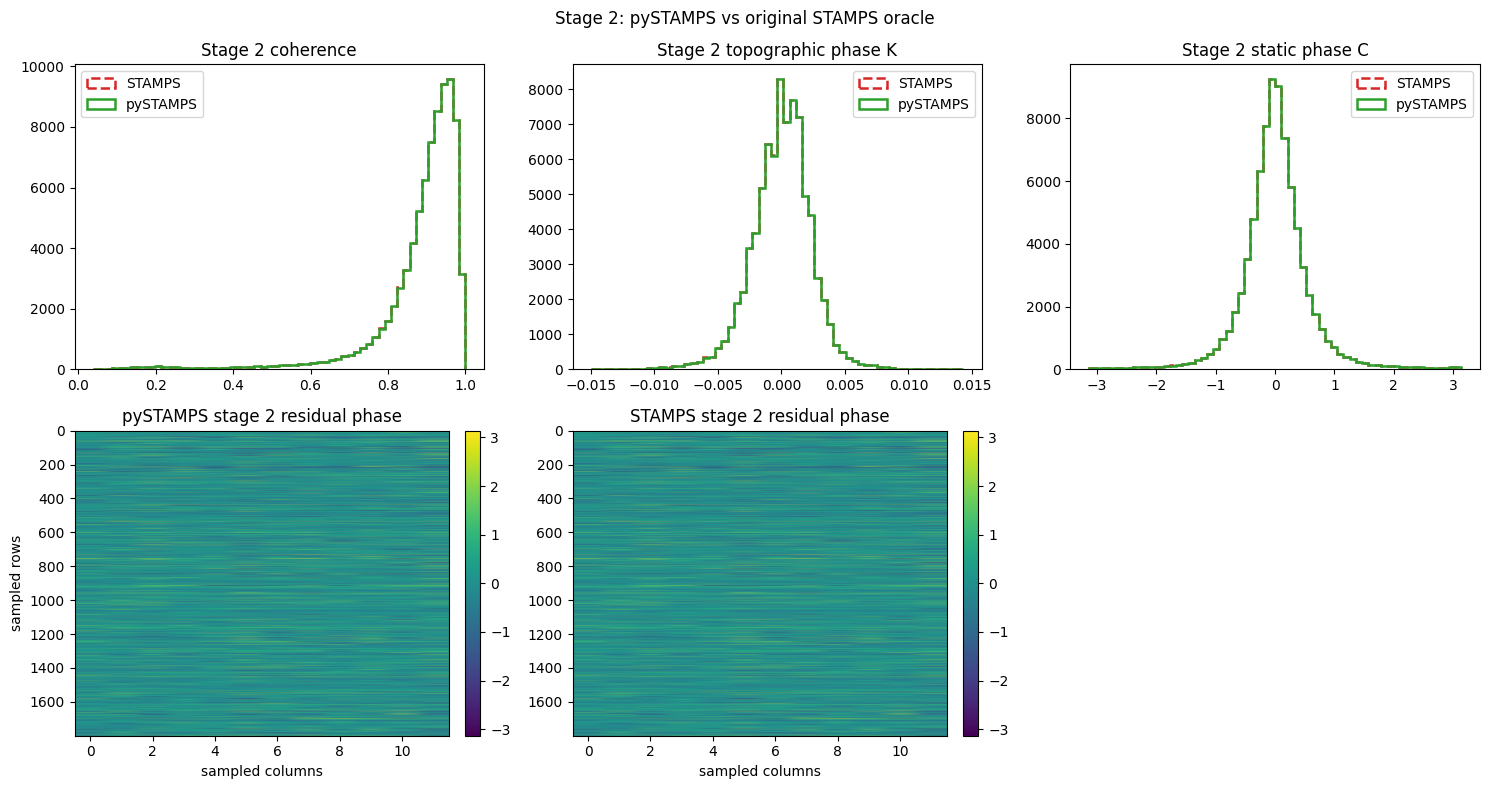

In [4]:
stage_2 = execute_stage(context, 2)
fig = plot_stage_comparison(context, 2)
plt.show()

## Stage 3. Select PS pixels

Apply the selection threshold and keep mask.

**Execution mode**  
latest pySTAMPS outputs (reused scratch artifacts)

**Legacy context**  
Legacy context: this is still inside legacy `stamps(1,4)`, but pySTAMPS isolates PS selection into stage 3.

**Python stage call**
```python
run_pipeline(PipelineContext(dataset_root=<repo-root>/inputs_and_outputs/validation_runs/notebook_stage_by_stage/fresh_run, start_step=3, end_step=3, run_config=<RunConfig>))
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| PATCH_1 | patch | skipped_existing | 0.00 | select1.mat present |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 0.01 | 0.20 | 0.21 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 1 | 0 | 1 | no |

**First verification failures**
| path | class | key | message |
| --- | --- | --- | --- |
| PATCH_1/select1.mat | Stage 3 patch boundary | C_ps2 | Value mismatch for key 'C_ps2', max_abs=6.14221 |

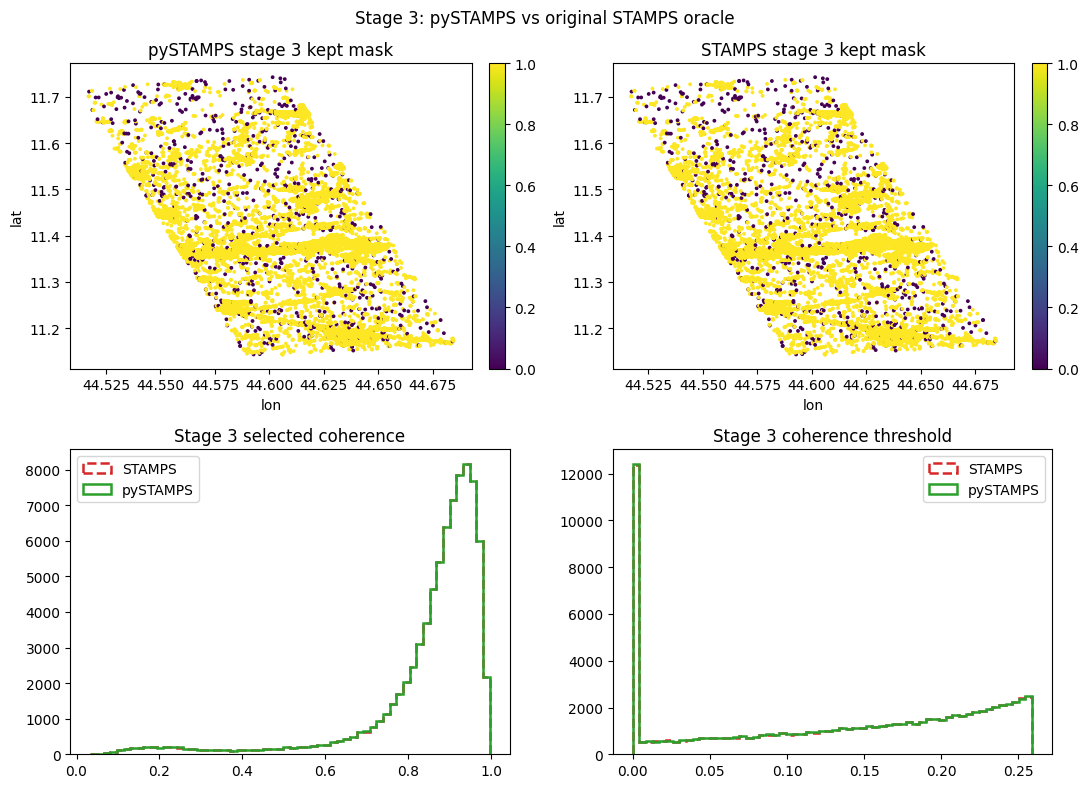

In [5]:
stage_3 = execute_stage(context, 3)
fig = plot_stage_comparison(context, 3)
plt.show()

## Stage 4. Weed adjacent pixels

Remove noisy and spatially redundant candidates.

**Execution mode**  
latest pySTAMPS outputs (reused scratch artifacts)

**Legacy context**  
Legacy context: this is still inside legacy `stamps(1,4)`, but pySTAMPS isolates weeding into stage 4.

**Python stage call**
```python
run_pipeline(PipelineContext(dataset_root=<repo-root>/inputs_and_outputs/validation_runs/notebook_stage_by_stage/fresh_run, start_step=4, end_step=4, run_config=<RunConfig>))
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| PATCH_1 | patch | skipped_existing | 0.01 | weed1.mat present |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 0.01 | 0.04 | 0.05 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 1 | 0 | 1 | no |

**First verification failures**
| path | class | key | message |
| --- | --- | --- | --- |
| PATCH_1/weed1.mat | Stage 4 patch boundary | ix_weed | Shape mismatch for key 'ix_weed': (79229,) != (79227,) |

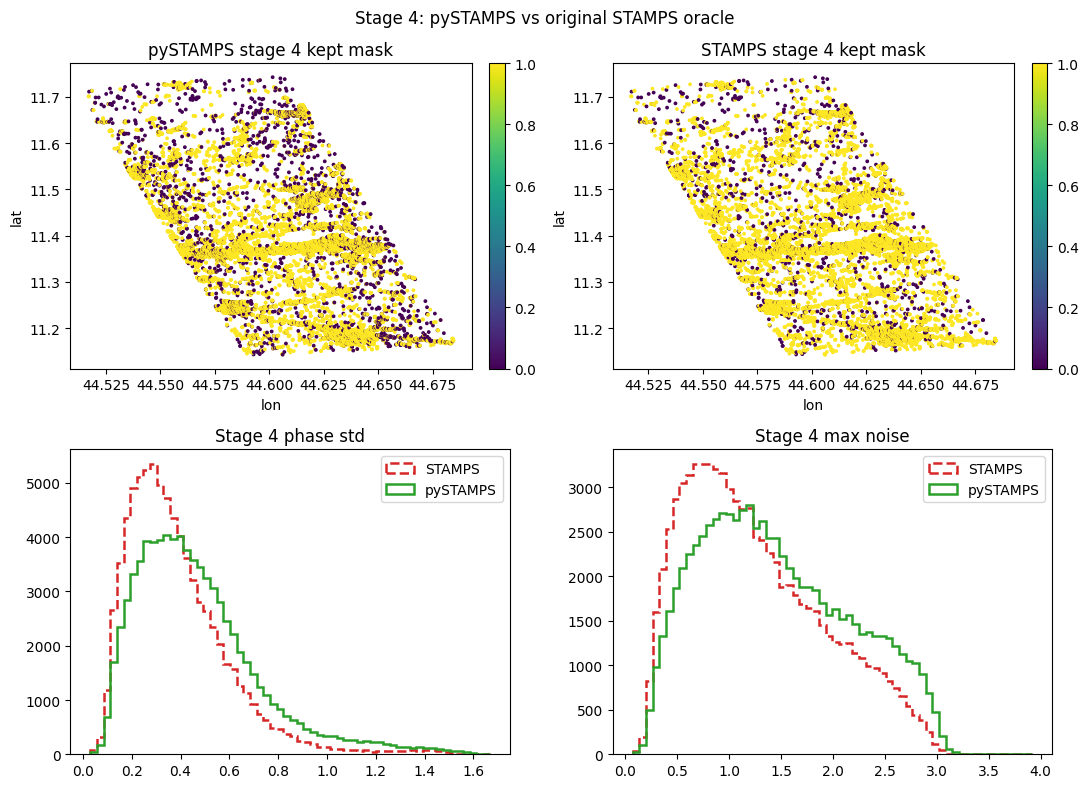

In [6]:
stage_4 = execute_stage(context, 4)
fig = plot_stage_comparison(context, 4)
plt.show()

## Stage 5. Correct phase and merge

Promote patch outputs and build merged dataset products.

**Execution mode**  
latest pySTAMPS outputs (reused scratch artifacts)

**Legacy context**  
Legacy context: `run_stamps_post.sh` moves into the merged dataset flow. pySTAMPS shows stage 5 explicitly before unwrapping.

**Python stage call**
```python
run_pipeline(PipelineContext(dataset_root=<repo-root>/inputs_and_outputs/validation_runs/notebook_stage_by_stage/fresh_run, start_step=5, end_step=5, run_config=<RunConfig>))
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| PATCH_1 | patch | completed | 5.10 | Stage 5 promoted 75583 PS to version 2 |
| fresh_run | merged | completed | 4.62 | Merged 1 patches into 75583 PS records |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 9.82 | 4.09 | 13.91 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 17 | 2 | 15 | no |

**First verification failures**
| path | class | key | message |
| --- | --- | --- | --- |
| PATCH_1/ps2.mat | Unclassified | ij | Shape mismatch for key 'ij': (75583, 3) != (77888, 3) |
| PATCH_1/ph2.mat | Unclassified | ph | Shape mismatch for key 'ph': (75583, 76) != (77888, 76) |
| PATCH_1/pm2.mat | Unwrap / smoothing | C_ps | Shape mismatch for key 'C_ps': (75583,) != (77888,) |
| PATCH_1/bp2.mat | Unclassified | bperp_mat | Shape mismatch for key 'bperp_mat': (75583, 75) != (77888, 75) |
| PATCH_1/hgt2.mat | Unclassified | hgt | Shape mismatch for key 'hgt': (75583,) != (77888,) |

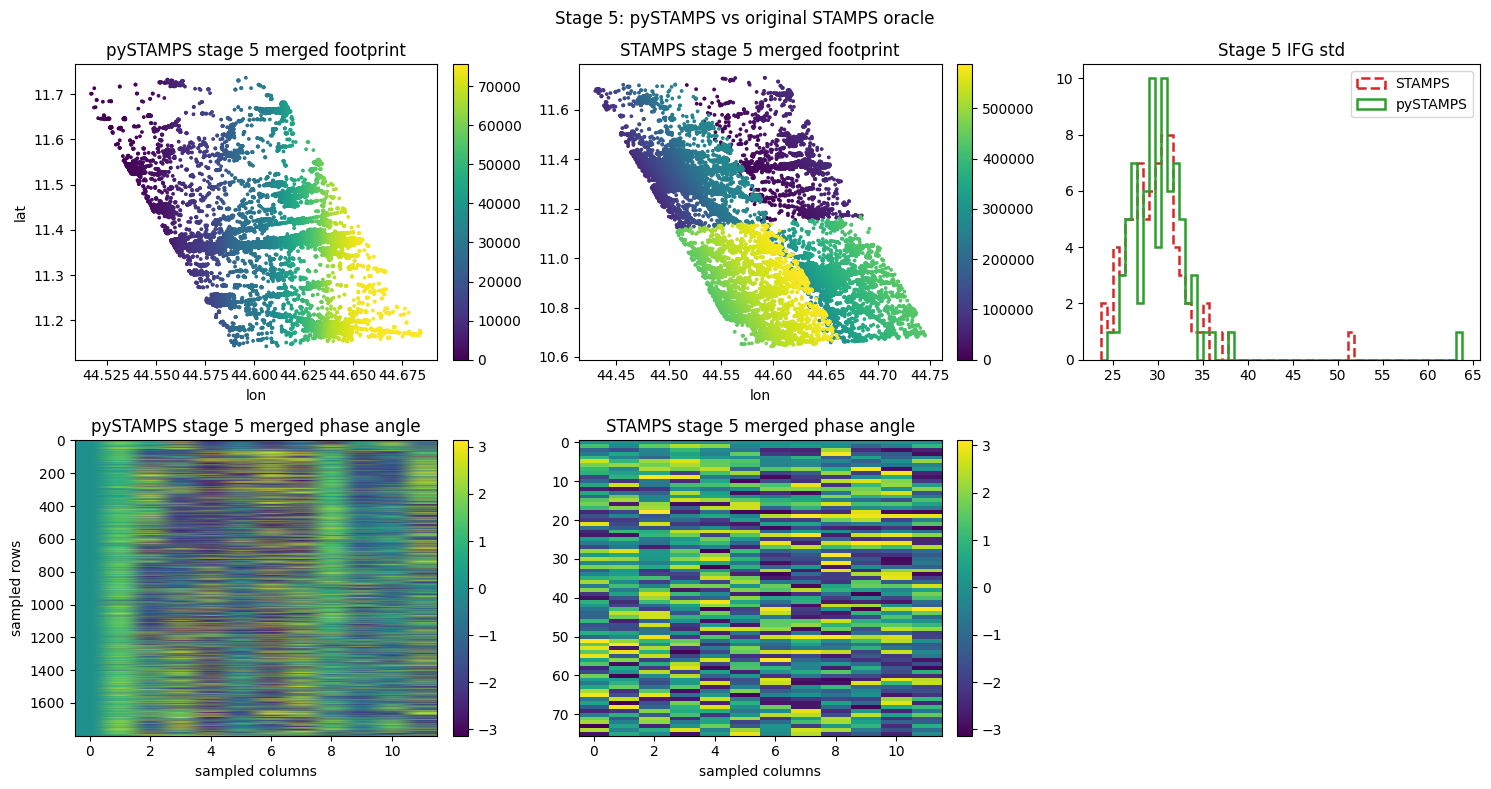

In [7]:
stage_5 = execute_stage(context, 5)
fig = plot_stage_comparison(context, 5)
plt.show()

## Stage 6. Unwrap phase

Run the unwrap stage with Triangle and SNAPHU.

**Execution mode**  
latest pySTAMPS outputs (reused scratch artifacts)

**Legacy context**  
Legacy context: the post script continues with merged outputs; pySTAMPS lets you inspect the unwrap products independently.

**Python stage call**
```python
run_pipeline(PipelineContext(dataset_root=<repo-root>/inputs_and_outputs/validation_runs/notebook_stage_by_stage/fresh_run, start_step=6, end_step=6, run_config=<RunConfig>))
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| fresh_run | merged | completed | 1106.57 | Stage 6 unwrapped 75583 PS across 76 interferograms |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 1106.59 | 0.49 | 1107.08 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 3 | 0 | 3 | no |

**First verification failures**
| path | class | key | message |
| --- | --- | --- | --- |
| ifgstd2.mat | Unwrap / smoothing | ifg_std | Value mismatch for key 'ifg_std', max_abs=12.4905 |
| phuw2.mat | Unwrap / smoothing | msd | Value mismatch for key 'msd', max_abs=13.9851 |
| uw_phaseuw.mat | Unwrap / smoothing | msd | Value mismatch for key 'msd', max_abs=13.9869 |

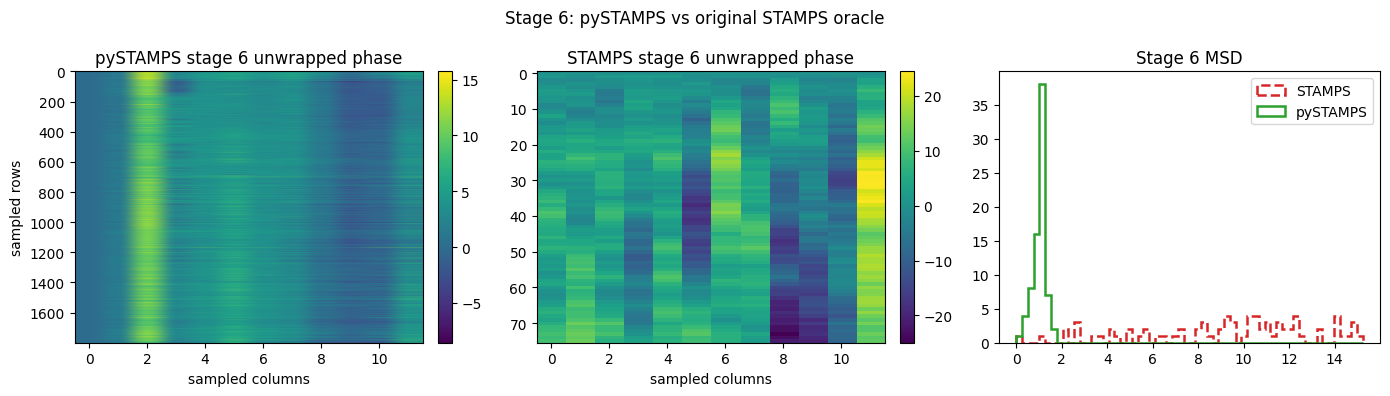

In [8]:
stage_6 = execute_stage(context, 6)
fig = plot_stage_comparison(context, 6)
plt.show()

## Stage 7. Calculate SCLA

Estimate and smooth spatially correlated look-angle error.

**Execution mode**  
latest pySTAMPS outputs (reused scratch artifacts)

**Legacy context**  
Legacy context: `run_stamps_post.sh` drives `stamps(5,7)`, so stage 7 owns the raw and smoothed SCLA artifacts.

**Python stage call**
```python
run_pipeline(PipelineContext(dataset_root=<repo-root>/inputs_and_outputs/validation_runs/notebook_stage_by_stage/fresh_run, start_step=7, end_step=7, run_config=<RunConfig>))
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| fresh_run | merged | completed | 4.31 | Stage 7 estimated SCLA for 75583 PS |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 4.35 | 0.94 | 5.29 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 2 | 1 | 1 | no |

**First verification failures**
| path | class | key | message |
| --- | --- | --- | --- |
| scla2.mat | Unwrapped-noise / statistics | C_ps_uw | Shape mismatch for key 'C_ps_uw': (75583,) != (587320,) |

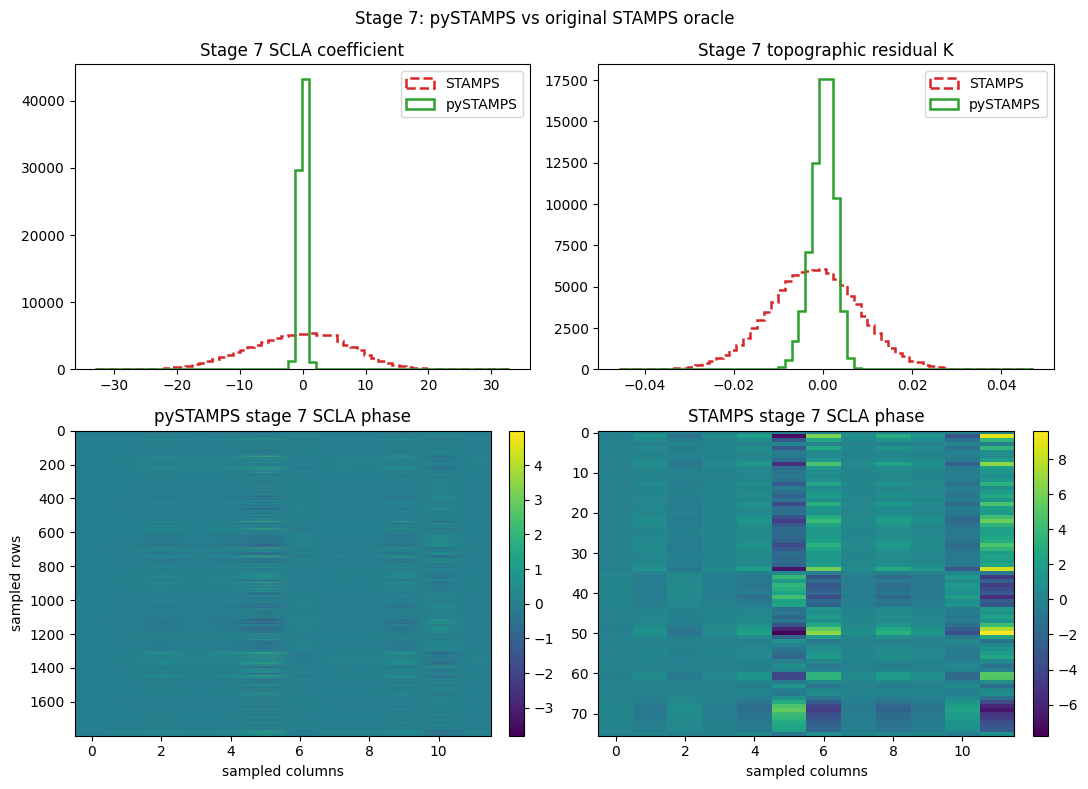

In [9]:
stage_7 = execute_stage(context, 7)
fig = plot_stage_comparison(context, 7)
plt.show()

## Stage 8. Filter SCN and mean velocity

Run final space-time filtering and velocity products.

**Execution mode**  
latest pySTAMPS outputs (reused scratch artifacts)

**Legacy context**  
Legacy context: the post wrapper follows `stamps(5,7)` with `stamps(6,6)` and plotting, so pySTAMPS uses stage 8 for the final rerun-backed `mean_v.mat` and `uw_space_time.mat` outputs.

**Python stage call**
```python
run_pipeline(PipelineContext(dataset_root=<repo-root>/inputs_and_outputs/validation_runs/notebook_stage_by_stage/fresh_run, start_step=8, end_step=8, run_config=<RunConfig>))
```

**Execution summary**
| target | scope | status | sec | details |
| --- | --- | --- | --- | --- |
| fresh_run | merged | completed | 588.17 | Stage 8 produced mean velocity and space-time noise model for 96597 arcs |

**Stage timing and tolerance**
| run sec | verify sec | total sec | tolerance |
| --- | --- | --- | --- |
| 588.18 | 0.59 | 588.77 | ToleranceConfig(rtol=1e-05, atol=1e-07, wrap_equivalence=True, wrap_period=6.283185307179586, wrap_keys=('ph_uw', 'ph', 'dph_noise', 'dph_space_uw')) |

**Stage-scoped verification**
| checked | matched | failed | all matched |
| --- | --- | --- | --- |
| 2 | 0 | 2 | no |

**First verification failures**
| path | class | key | message |
| --- | --- | --- | --- |
| mean_v.mat | Unwrapped-noise / statistics | m | Shape mismatch for key 'm': (2, 75583) != (2, 587320) |
| uw_space_time.mat | Unwrapped-noise / statistics | dph_noise | Shape mismatch for key 'dph_noise': (96597, 75) != (75, 587320) |

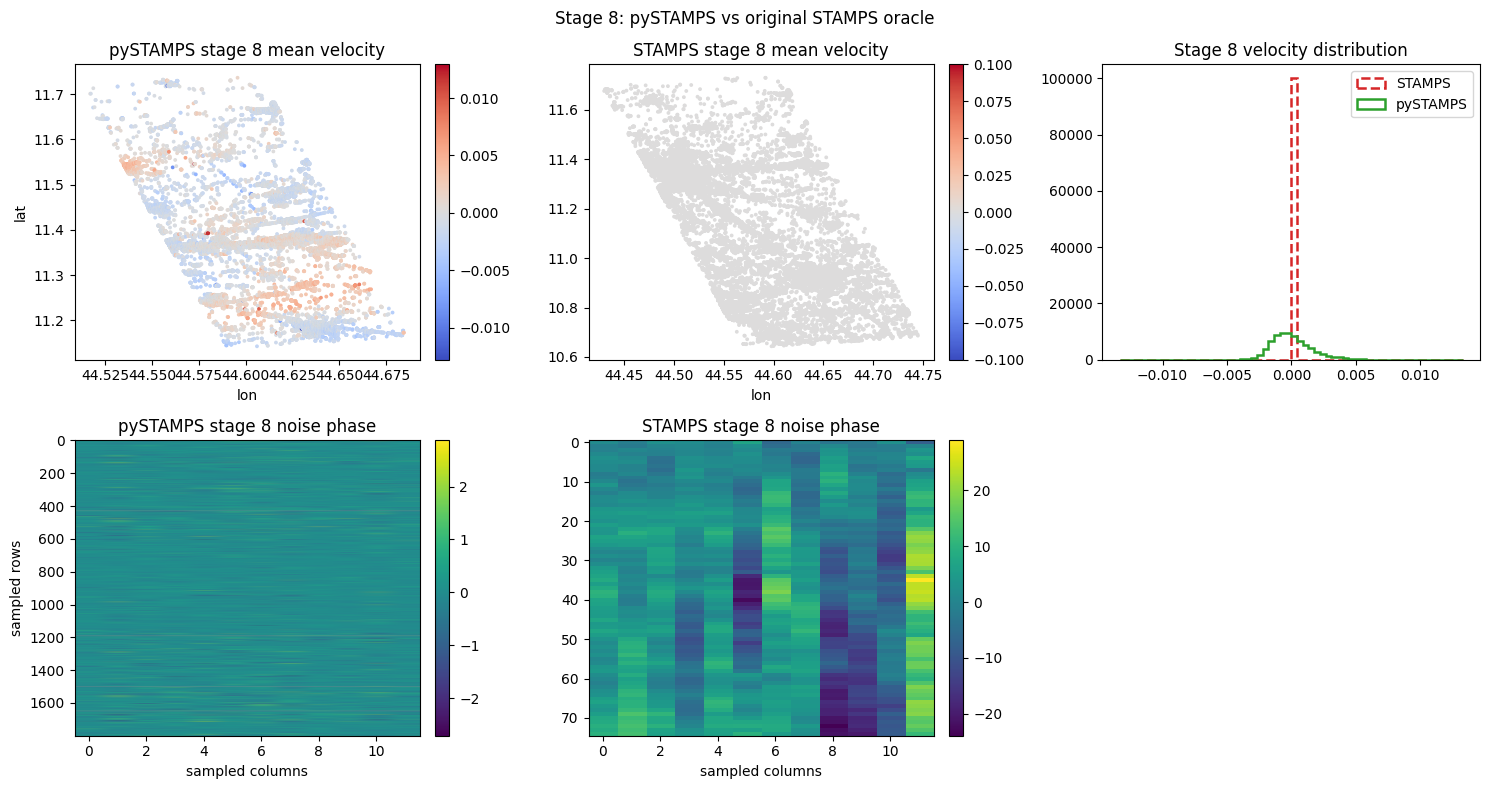

In [10]:
stage_8 = execute_stage(context, 8)
fig = plot_stage_comparison(context, 8)
plt.show()

## Final summary

In [11]:
stage_results = [stage_1, stage_2, stage_3, stage_4, stage_5, stage_6, stage_7, stage_8]
print("stage | mode | checked | failed | matched")
for item in stage_results:
    run = item["run"]
    verify = item["verify"]
    print(
        f"{run['stage_id']:>5} | {run['execution_mode']} | "
        f"{verify['checked']:>7} | {verify['failed']:>6} | {verify['ok']}"
    )

print(f"scratch dataset: {context.scratch_root}")

stage | mode | checked | failed | matched
    1 | latest pySTAMPS outputs (reused scratch artifacts) |       5 |      0 | True
    2 | latest pySTAMPS outputs (reused scratch artifacts) |       1 |      1 | False
    3 | latest pySTAMPS outputs (reused scratch artifacts) |       1 |      1 | False
    4 | latest pySTAMPS outputs (reused scratch artifacts) |       1 |      1 | False
    5 | latest pySTAMPS outputs (reused scratch artifacts) |      17 |     15 | False
    6 | latest pySTAMPS outputs (reused scratch artifacts) |       3 |      3 | False
    7 | latest pySTAMPS outputs (reused scratch artifacts) |       2 |      1 | False
    8 | latest pySTAMPS outputs (reused scratch artifacts) |       2 |      2 | False
scratch dataset: <repo-root>/inputs_and_outputs/validation_runs/notebook_stage_by_stage/fresh_run
